# 03 · Modelling data contract: homes, labels, splits and leakage controls

**Requirement 3 (first half).** Before training anything, fix *which* data the model may
learn from and *how* it is evaluated, and prove that no information leaks from evaluation
into training.

| | |
|---|---|
| **Input** | 1-minute official cleaned data (`io.load_clean_minutes`, true UTC) |
| **Output** | `artifacts/metrics/nb03_split_manifest.json`, `artifacts/tables/nb03_*` |
| **Code** | `src/refit_nilm/datasets.py` (tests in `tests/test_datasets.py`) |
| **Run time** | about 2 minutes |

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from refit_nilm import datasets as D
from refit_nilm import io, metrics, plots
from refit_nilm import config as C

warnings.filterwarnings("ignore", category=FutureWarning)
plots.setup()
pd.set_option("display.width", 160, "display.max_columns", 30)
P = plots.PALETTE
amap = io.parse_appliance_map(C.DATA_DIR / "CLEAN_READ_ME_081116.txt")
WM = io.washing_machine_channels(amap)
WD = io.washer_dryer_channels(amap)
MANIFEST: dict = {}

## 1. Which homes, and why

**Validation design.** The question a utility cares about is "will this work in a home we have
never metered?", so the primary test is an **unseen house**. I use the split that has become
the reference for REFIT washing machines since D'Incecco, Squartini & Zhong (IEEE TSG 2020):

| role | houses |
|---|---|
| train | 2, 5, 7, 9, 15, 16, 17 |
| validation (early stopping, model selection) | 18 |
| test (touched once, at the end) | 8 |

Using the reference split makes the results comparable in spirit with published numbers;
exact comparison is not possible because those papers use 8-second data.

**Additional unseen houses.** One test house is a thin basis for a claim about
generalisation (Klemenjak et al. 2019 recommend reporting error over several unseen homes).
Houses 1, 6, 10, 19 and 20 have one washing machine, no PV and no documented WM change, and
are not used for training or selection, so they are evaluated as further unseen homes.

**Excluded from modelling, with reasons:**
* House 12: no washing-machine monitor.
* House 4: two washing machines in use at once; a single-appliance target is ambiguous.
* House 13: the washing machine was replaced on 25 Mar 2015 (README), so the label changes
  meaning mid-record.
* Houses 3, 11, 21: rooftop PV distorts the aggregate (Murray et al. 2017).

**Seen-house check.** The last 20 % of each training house's record is held out as a
*seen-house temporal test*: same homes, later period. The gap between seen and unseen
performance (Klemenjak's generalisation loss) shows how much of the model's skill is
home-specific.

In [2]:
TRAIN, VAL, TEST = C.TRAIN_HOUSES, C.VAL_HOUSE, C.TEST_HOUSE
EXTRA_UNSEEN = C.EXTRA_UNSEEN_HOUSES
ALL = TRAIN + [VAL, TEST] + EXTRA_UNSEEN
roles = {**{h: "train (+ seen test)" for h in TRAIN}, VAL: "validation", TEST: "test", **{h: "extra unseen" for h in EXTRA_UNSEEN}}
assert io.check_against_reference(WM) == [], "README mapping disagrees with the reference code"
channels = {h: f"Appliance{WM[h][0]}" for h in ALL}
minutes = {h: io.load_clean_minutes(h) for h in ALL}
frames = {h: D.house_frame(h, channels[h], minutes[h]) for h in ALL}

## 2. Label quality per home

**Why.** The model is only as good as its labels. Four things reduce label quality in REFIT:
missing minutes, forward-filled flat lines (outages disguised as data, notebook 02), minutes
where the plug monitors add up to more than the aggregate (`issues`), and **unmetered load**,
i.e. everything in the house that no plug monitor sees. The last is measured by the
noise-to-aggregate ratio (NAR, Klemenjak et al. 2020): the share of aggregate energy not
explained by the nine monitors. A high NAR means more unexplained activity that can be
confused with the washing machine.

In [3]:
rows = []
for h in ALL:
    f, m = frames[h], minutes[h]
    ok = f["target_ok"]
    rows.append(
        {
            "house": h, "role": roles[h], "wm_channel": channels[h],
            "washer_dryer_too": bool(WD.get(h)),
            "start": f.index.min().date(), "end": f.index.max().date(),
            "minutes": len(f),
            "usable_target_pct": round(100 * ok.mean(), 1),
            "missing_or_flat_pct": round(100 * f["agg_missing"].mean(), 1),
            "issues_pct": round(100 * f["issues"].mean(), 2),
            "wm_on_pct_of_usable": round(100 * (f.loc[ok, "wm"] >= C.WM_ON_THRESHOLD_W).mean(), 2),
            "NAR_pct": round(100 * metrics.noise_to_aggregate_ratio(m["Aggregate"], m[C.CHANNELS[1:]]), 1),
            "wm_share_of_aggregate_energy_pct": round(100 * f.loc[ok, "wm"].sum() / f.loc[ok, "agg"].sum(), 2),
        }
    )
quality = pd.DataFrame(rows)
quality.to_csv(C.TABLE_DIR / "nb03_label_quality.csv", index=False)
quality

,house,role,wm_channel,washer_dryer_too,start,end,minutes,usable_target_pct,missing_or_flat_pct,issues_pct,wm_on_pct_of_usable,NAR_pct,wm_share_of_aggregate_energy_pct
0,2,train (+ seen test),Appliance2,False,2013-09-17,2015-05-28,889018,73.2,25.3,1.51,4.01,69.0,3.74
1,5,train (+ seen test),Appliance3,False,2013-09-26,2015-07-06,933533,83.0,9.6,7.59,6.06,59.4,2.54
2,7,train (+ seen test),Appliance5,False,2013-11-01,2015-07-08,882910,82.9,13.1,4.06,6.78,58.2,5.94
3,9,train (+ seen test),Appliance3,True,2013-12-17,2015-07-08,817947,77.9,20.0,2.02,2.04,63.1,2.01
4,15,train (+ seen test),Appliance3,False,2013-12-17,2015-07-08,816947,84.2,14.4,1.40,1.94,66.7,4.76
5,16,train (+ seen test),Appliance5,False,2014-01-10,2015-07-08,782773,80.4,18.8,0.80,3.61,62.9,3.42
6,17,train (+ seen test),Appliance4,False,2014-03-06,2015-06-19,676650,87.8,8.2,4.01,1.37,58.6,1.60
7,18,validation,Appliance5,True,2014-03-07,2015-05-24,637922,87.5,7.8,5.47,1.01,47.1,0.86
8,8,test,Appliance4,True,2013-11-01,2015-05-10,799224,87.3,11.2,1.54,2.84,79.6,3.67
9,1,extra unseen,Appliance5,True,2013-10-09,2015-07-10,920031,85.3,12.9,1.81,1.28,67.6,1.00


**Reading the table.**
* The washing machine is on in only 2–9 % of usable minutes and carries 1–3 % of the house's
  energy: a sparse, small target.
* NAR is high everywhere (most of each home's consumption is not plug-monitored), and House 8,
  the test house, is among the highest. Published REFIT numbers on House 8 come from the same
  difficulty.
* Houses 1, 8 and 18 also have a washer-dryer on a separate channel; its heating phase looks
  like the washing machine's in the aggregate, so these homes are where false positives are
  expected.

## 3. Window length

Seq2Point predicts the appliance's power at the centre of a window of aggregate readings, so
the window must cover a whole cycle on either side of the predicted minute to see the cycle's
beginning and end. Notebook 02 measured the 90th percentile of cycle duration at 118 minutes,
which gives **W = 237 minutes** (2 × 118 + 1, odd so there is a centre). The reference
implementation used 599 samples at 8 s ≈ 80 minutes; its time-equivalent at 1 minute,
**W = 81**, is the alternative. Both are built here; notebook 04 chooses between them on the
validation house only.

In [4]:
WINDOWS = [81, 237]
spec = D.SplitSpec()
corpora, audits, gaps = {}, [], []
for W in WINDOWS:
    labels = D.assign_splits(frames, D.SplitSpec(test_houses=[TEST] + EXTRA_UNSEEN), W)
    corpora[W] = D.build_corpus(frames, labels, W)
    audits.append(D.leakage_audit(corpora[W]).assign(window=W))
    gaps.append(D.temporal_gap_check(corpora[W]))
audit = pd.concat(audits, ignore_index=True)
audit.to_csv(C.TABLE_DIR / "nb03_leakage_audit.csv", index=False)
audit

,split,windows,houses,windows_spanning_two_labels,windows_spanning_two_houses,first_target_utc,last_target_utc,window
0,train,3759548,"[2, 5, 7, 9, 15, 16, 17]",0,0,2013-09-17 22:48:00,2015-03-21 07:15:00,81
1,seen_test,871885,"[2, 5, 7, 9, 15, 16, 17]",0,0,2015-01-25 21:43:00,2015-07-08 17:12:00,81
2,val,553394,[18],0,0,2014-03-07 11:13:00,2015-05-22 13:27:00,81
3,test,3979448,"[1, 6, 8, 10, 19, 20]",0,0,2013-10-09 13:46:00,2015-07-10 10:16:00,81
4,train,3750007,"[2, 5, 7, 9, 15, 16, 17]",0,0,2013-09-18 00:06:00,2015-03-21 05:57:00,237
5,seen_test,866169,"[2, 5, 7, 9, 15, 16, 17]",0,0,2015-01-26 01:37:00,2015-07-08 15:54:00,237
6,val,549129,[18],0,0,2014-03-07 12:31:00,2015-05-22 10:08:00,237
7,test,3972771,"[1, 6, 8, 10, 19, 20]",0,0,2013-10-09 15:04:00,2015-07-10 08:58:00,237


## 4. Leakage controls

| risk | control | evidence |
|---|---|---|
| a test home's data used in training | split by **house**; test homes never enter training, validation or normalisation | `houses` column above |
| a window straddling two splits or two homes | windows are only valid if every minute carries the same split label; homes are separated by a block of missing minutes | `windows_spanning_two_*` = 0 above |
| seen-test windows overlapping training inputs | an embargo of one day plus one window between each training house's train and seen-test periods | gap table below |
| normalisation statistics computed on test data | mean/std from training targets only | section 5 |
| thresholds, window, loss weight or epochs tuned on test data | all chosen on House 18 only; House 8 is evaluated once, at the end | notebook 04–06 |
| target information in the input | inputs are aggregate power only; no sub-meter channel, no derived label | `datasets.build_corpus` |
| missing data read as "off" | missing / flat-line minutes are never targets; windows with > 10 % missing input are dropped | `target_ok`, `max_missing_frac` |

In [5]:
gap_tab = pd.concat(gaps, ignore_index=True)
assert gap_tab["ok"].all() and (audit["windows_spanning_two_labels"] == 0).all() and (audit["windows_spanning_two_houses"] == 0).all()
gap_tab

,house,gap_minutes,window,ok
0,2,1522.0,81,True
1,5,1522.0,81,True
2,7,1522.0,81,True
3,9,1522.0,81,True
4,15,1522.0,81,True
5,16,4760.0,81,True
6,17,1522.0,81,True
7,2,1678.0,237,True
8,5,1678.0,237,True
9,7,1678.0,237,True


## 5. Normalisation statistics (training targets only)

In [6]:
stats = {W: D.standardisation(corpora[W]) for W in WINDOWS}
st = pd.DataFrame(stats).T.round(1)
st["reference_8s (D'Incecco/Zhong)"] = "agg 522 ± 814, WM 400 ± 700"
st

,agg_mean,agg_std,wm_mean,wm_std,reference_8s (D'Incecco/Zhong)
81,493.4,760.8,15.8,157.4,"agg 522 ± 814, WM 400 ± 700"
237,493.4,761.1,15.9,157.6,"agg 522 ± 814, WM 400 ± 700"


The aggregate statistics are close to the reference constants. The WM statistics are not
comparable: the reference values are fixed constants chosen for scaling, while mine are
computed over all training minutes, most of which are "off".

## 6. Class balance per split

In [7]:
bal = []
for W in WINDOWS:
    cp = corpora[W]
    for lab in ("train", "seen_test", "val", "test"):
        y = cp.wm[cp.targets(lab)]
        bal.append({"window": W, "split": lab, "targets": len(y), "on_pct": round(100 * (y >= C.WM_ON_THRESHOLD_W).mean(), 2), "energy_kwh": round(np.nansum(y) / 60_000, 1)})
bal = pd.DataFrame(bal)
bal.to_csv(C.TABLE_DIR / "nb03_class_balance.csv", index=False)
bal.pivot(index="split", columns="window", values=["targets", "on_pct"])

targets            on_pct      
window           81         237    81    237
split                                       
seen_test   871885.0   866169.0   4.45  4.42
test       3979448.0  3972771.0   3.20  3.20
train      3759548.0  3750007.0   3.65  3.66
val         553394.0   549129.0   1.00  1.01

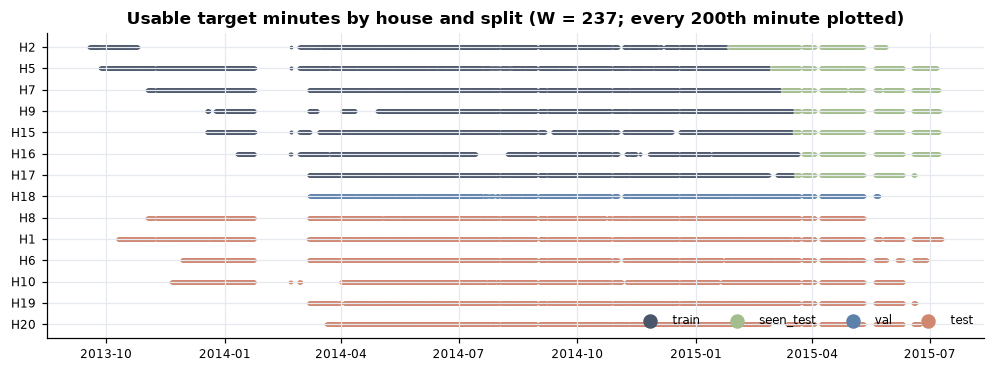

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.6))
cp = corpora[237]
ylab = {"train": 0, "seen_test": 0, "val": 1, "test": 2}
colors = {"train": P["aggregate"], "seen_test": P["alt"], "val": P["pred"], "test": P["wm"]}
order = TRAIN + [VAL, TEST] + EXTRA_UNSEEN
for lab in ("train", "seen_test", "val", "test"):
    t = cp.targets(lab)
    hh = cp.house[t]
    tt = pd.to_datetime(cp.time[t], unit="s")
    yy = np.array([order.index(h) for h in hh])
    ax.scatter(tt[::200], yy[::200], s=2, color=colors[lab], label=lab)
ax.set_yticks(range(len(order)), [f"H{h}" for h in order])
ax.invert_yaxis()
ax.set_title("Usable target minutes by house and split (W = 237; every 200th minute plotted)")
ax.legend(loc="lower right", ncol=4, markerscale=6)
plots.save(fig, "nb03_split_timeline")
plt.show()

## 7. Missing labels, appliance changes and unmetered loads

* **Missing labels.** A plug monitor that drops out leaves no label; the cleaned release
  forward-fills it, which turns an outage into a flat line, and the official release sets
  faulty readings above 4 kW to 0, which turns a fault into "off". Here, missing and flat
  minutes are never used as targets, and windows with more than 10 % missing input are dropped.
  What cannot be fixed: a WM that was unplugged or moved without notice still reads 0 and looks
  like a home that does no laundry. Per-home cycle frequency (notebook 02) is the check for that.
* **Appliance changes.** House 13's machine was replaced in March 2015 and House 4 has two, so
  both are excluded. A new machine with a different heater or programme set would shift the
  signature and reduce accuracy until the model is re-validated.
* **Unmetered loads.** With NAR above 50 % in most homes, the aggregate contains large loads
  (electric showers, ovens, immersion heaters) that no label explains. The model must learn to
  ignore them; when one of them looks like a WM heating phase, it produces false positives.
  The plug-monitor sum exceeding the aggregate (`issues`) is the opposite case, a timing
  mismatch between unsynchronised sensors; those minutes are excluded from training and scoring.

In [9]:
MANIFEST.update(
    {
        "train_houses": TRAIN, "val_house": VAL, "test_house": TEST, "extra_unseen_houses": EXTRA_UNSEEN,
        "excluded": {"12": "no WM monitor", "4": "two WMs", "13": "WM replaced 2015-03-25", "3": "PV", "11": "PV", "21": "PV"},
        "wm_channels": channels, "windows": WINDOWS, "seen_test_frac": spec.seen_test_frac, "embargo_days": spec.embargo_days,
        "max_missing_frac": 0.10, "on_threshold_w": C.WM_ON_THRESHOLD_W,
        "stats": {str(W): stats[W] for W in WINDOWS},
        "windows_per_split": {str(W): {k: int(len(v)) for k, v in corpora[W].starts.items()} for W in WINDOWS},
        "periods": {str(h): [str(frames[h].index.min()), str(frames[h].index.max())] for h in ALL},
    }
)
with open(C.METRIC_DIR / "nb03_split_manifest.json", "w") as fh:
    json.dump(MANIFEST, fh, indent=2, default=str)
print(json.dumps(MANIFEST["windows_per_split"], indent=1))

{
 "81": {
  "train": 3759548,
  "seen_test": 871885,
  "val": 553394,
  "test": 3979448
 },
 "237": {
  "train": 3750007,
  "seen_test": 866169,
  "val": 549129,
  "test": 3972771
 }
}


## Summary

**Homes and periods.**

| role | houses | period | usable target minutes (W = 237) |
|---|---|---|---|
| train | 2, 5, 7, 9, 15, 16, 17 (first ~80 % of each record) | Sep 2013 – Mar 2015 | 3.75 M |
| seen-house test | same houses, last ~20 % after a 1-day + 1-window embargo | Jan – Jul 2015 | 0.87 M |
| validation | 18 | Mar 2014 – May 2015 | 0.55 M |
| unseen test | 8 (reference test house) + 1, 6, 10, 19, 20 | Oct 2013 – Jul 2015 | 3.97 M |

Excluded: House 12 (no WM), 4 (two WMs), 13 (WM replaced), 3, 11, 21 (PV).

**Labels.** 73–89 % of each home's minutes are usable targets once missing minutes,
forward-filled flat runs and `issues` minutes are removed. The washing machine is on in 1–9 %
of usable minutes and accounts for 1–6 % of household energy. Unmetered load is high
everywhere (NAR 47–80 %); House 8, the test house, has the highest at 80 %, in line with the
78 % reported by Klemenjak et al. for the same house.

**Leakage.** Zero windows span two splits or two homes; every training house has at least
1,678 minutes (> 1 day) between its last training input and its first seen-test input;
normalisation statistics come from training targets only (aggregate 493 ± 761 W, close to the
reference 522 ± 814 W at 8 s). The validation house is the only data used for any choice.

**A caution on validation.** House 18 is the sparsest home in the set (WM on in 1 % of
minutes) and also owns a washer-dryer, so validation scores will be pessimistic and noisy.
I keep it because it is the reference choice; model selection therefore uses more than one
metric (notebook 04).

## Verification log

* `tests/test_datasets.py` builds synthetic homes and asserts the same properties as the audit
  above (no cross-split or cross-house windows, embargo respected, missing-fraction cap,
  training-only statistics).
* Spot check: the first and last target timestamps per split in the audit table match the
  house date ranges in the label-quality table.

**Next:** `04_baselines_and_seq2point` trains the baselines and the reference model.